# Beekeeper — Notebook 01: Análisis Exploratorio de Datos

**Proyecto Final IA** — Curso de Especialización en Inteligencia Artificial y Big Data — IES Azarquiel

---

## Contexto

El proyecto desarrolla un sistema de diagnóstico de salud de colmenas a partir de grabaciones de audio del zumbido. El objetivo final es una aplicación web donde un apicultor sube un audio corto y obtiene una clasificación del estado de su colonia, sin necesidad de hardware adicional.

Este primer notebook se centra en **explorar y entender el dataset** antes de diseñar el modelo. Cubrimos seis bloques:

1. **Verificación del dataset** — qué tenemos y cómo está organizado.
2. **Distribución de las clases** — equilibrio y reparto entre colmenas.
3. **Análisis temporal** — rango de fechas y posible sesgo temporal.
4. **Análisis técnico de los audios** — duración, sample rate, calidad.
5. **Análisis acústico** — visualización de espectrogramas por clase.
6. **Conclusiones y decisiones** — qué se decide a partir de lo observado.

Las decisiones que se documentan en el bloque 6 sirven de base para el preprocesado del notebook 02.

## Configuración inicial

In [ ]:
!pip install -q librosa

In [16]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DATA_DIR    = Path.cwd().parent / 'data'
RUTA_AUDIOS = DATA_DIR / 'sound_files'


QUEEN_STATUS_NOMBRES = {
    0: 'Reina original',
    1: 'Sin reina',
    2: 'Reina nueva rechazada',
    3: 'Reina nueva aceptada',
}

COLORES_CLASES = {
    0: '#10B981',
    1: '#EF4444',
    2: '#F59E0B',
    3: '#3B82F6',
}

print('DATA_DIR    :', DATA_DIR)
print('RUTA_AUDIOS :', RUTA_AUDIOS)


DATA_DIR    : d:\abejas\ENTREGA\data
RUTA_AUDIOS : d:\abejas\ENTREGA\data\sound_files


---

## 1. Verificación del dataset

Antes de mirar nada estadístico necesitamos asegurarnos de que los datos están completos y entender su estructura física en disco.

### 1.1 Carga del CSV de etiquetas

El fichero `all_data_updated.csv` contiene una fila por cada grabación original con sus metadatos y etiquetas (entre ellas, `queen status` que será nuestra etiqueta principal).

In [17]:
main_dataset = pd.read_csv(DATA_DIR / 'all_data_updated.csv')
print(f'Shape del CSV: {main_dataset.shape}')
print(f'Columnas ({len(main_dataset.columns)}): {main_dataset.columns.tolist()}')
main_dataset.head(3)

Shape del CSV: (1275, 23)
Columnas (23): ['device', 'hive number', 'date', 'hive temp', 'hive humidity', 'hive pressure', 'weather temp', 'weather humidity', 'weather pressure', 'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain', 'lat', 'long', 'file name', 'queen presence', 'queen acceptance', 'frames', 'target', 'time', 'queen status']


,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,rain,lat,long,file name,queen presence,queen acceptance,frames,target,time,queen status
0,1,5,2022-06-08 14:52:28,36.42,30.29,1007.45,26.68,52,1013,8.75,...,0,37.29,-121.95,2022-06-08--14-52-28_1.raw,1,2,8,0,0.583,0
1,1,5,2022-06-08 15:51:41,33.56,33.98,1006.93,25.99,53,1012,10.29,...,0,37.29,-121.95,2022-06-08--15-51-41_1.raw,1,2,8,0,0.625,0
2,1,5,2022-06-08 17:21:53,29.01,42.73,1006.68,24.49,56,1012,8.75,...,0,37.29,-121.95,2022-06-08--17-21-53_1.raw,0,0,8,1,0.708,1


### 1.2 Construcción del mapeo segmento → original

Generamos una columna `base` (sin `__segmentN.wav` y con `.raw`) para cada fichero de disco, y comprobamos que se enlaza correctamente con el CSV.

In [18]:
archivos_en_csv = set(main_dataset['file name'].tolist())
archivos_en_disco = set(os.listdir(RUTA_AUDIOS))
def segmento_a_original(nombre_segmento: str) -> str:
    return re.sub(r'__segment\d+\.wav$', '.raw', nombre_segmento)


df_segmentos = pd.DataFrame({
    'segmento': sorted(archivos_en_disco),
})
df_segmentos['file name'] = df_segmentos['segmento'].apply(segmento_a_original)

Distribución de segmentos por audio original:
count    1222.00
mean        5.81
std         0.79
min         1.00
25%         6.00
50%         6.00
75%         6.00
max         6.00
dtype: float64


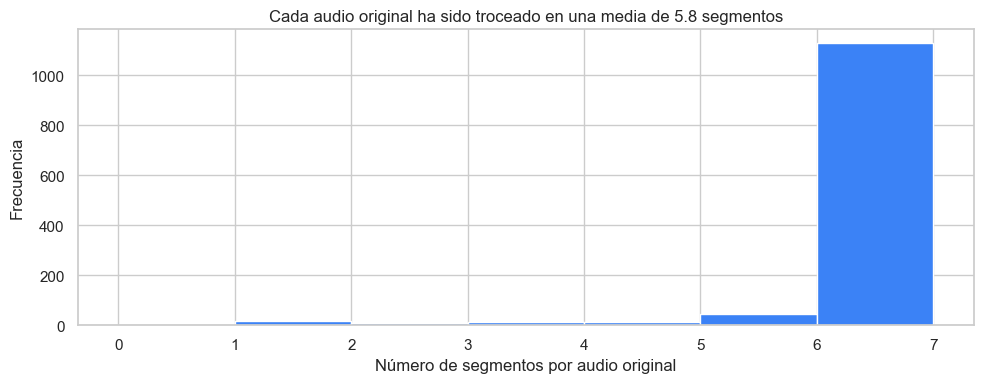

In [19]:
segs_por_original = df_segmentos.groupby('file name').size()
print('Distribución de segmentos por audio original:')
print(segs_por_original.describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(segs_por_original, bins=range(0, segs_por_original.max() + 2), color='#3B82F6', edgecolor='white')
ax.set_xlabel('Número de segmentos por audio original')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Cada audio original ha sido troceado en una media de '
             f'{segs_por_original.mean():.1f} segmentos')
plt.tight_layout()
plt.show()

### 1.3 DataFrame de trabajo a nivel de segmento

Hacemos el `join` entre los segmentos y el CSV original. El resultado es un DataFrame de ~7100 filas donde cada segmento tiene asociadas todas las etiquetas y metadatos de su grabación padre. Este DataFrame es el que vamos a usar a partir de aquí.

In [20]:
df = df_segmentos.merge(main_dataset, on='file name', how='left')

print(f'Shape del DataFrame de trabajo: {df.shape}')
print(f'Segmentos sin etiqueta tras el join: {df["queen status"].isna().sum()}')
df.head(3)

Shape del DataFrame de trabajo: (7100, 24)
Segmentos sin etiqueta tras el join: 0


,segmento,file name,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,...,cloud coverage,rain,lat,long,queen presence,queen acceptance,frames,target,time,queen status
0,2022-06-05--17-41-01_2__segment0.wav,2022-06-05--17-41-01_2.raw,2,3,2022-06-05 17:41:01,29.84,43.53,1007.27,24.15,68,...,75,0,37.29,-121.95,1,2,10,5,0.708,0
1,2022-06-05--17-41-01_2__segment1.wav,2022-06-05--17-41-01_2.raw,2,3,2022-06-05 17:41:01,29.84,43.53,1007.27,24.15,68,...,75,0,37.29,-121.95,1,2,10,5,0.708,0
2,2022-06-05--17-41-01_2__segment2.wav,2022-06-05--17-41-01_2.raw,2,3,2022-06-05 17:41:01,29.84,43.53,1007.27,24.15,68,...,75,0,37.29,-121.95,1,2,10,5,0.708,0


---

## 2. Distribución de las clases

Análisis del balance entre clases y de cómo están repartidas entre colmenas y dispositivos.

### 2.1 Conteo de `queen status` (a nivel de segmento)

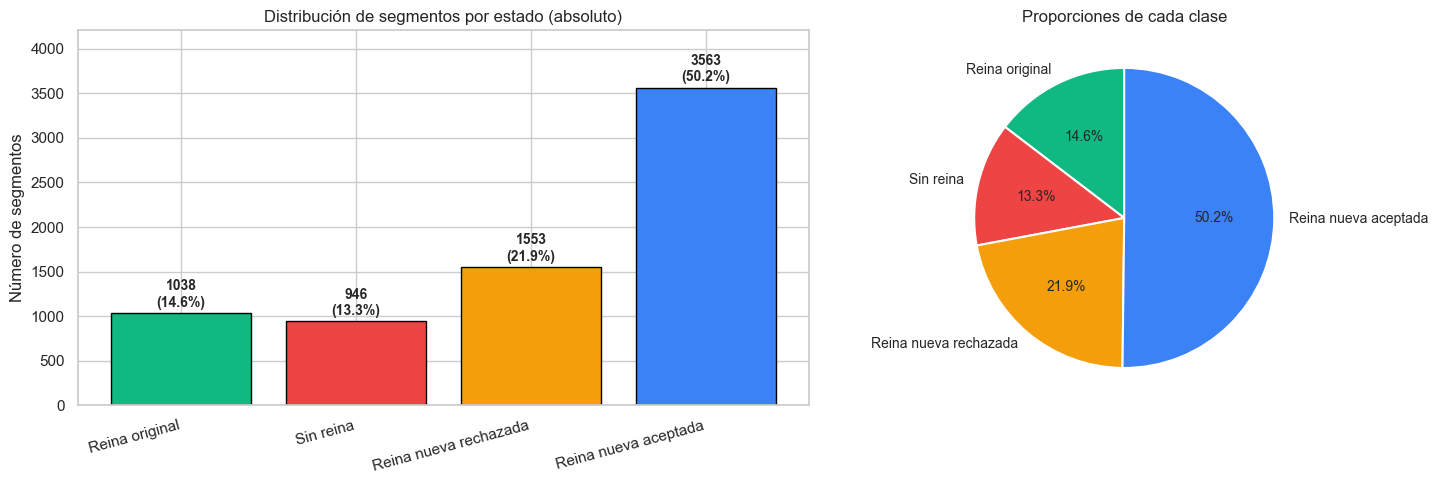

Ratio mayoritaria/minoritaria: 3.77×  (mayoritaria: Reina nueva aceptada = 3563,  minoritaria: Sin reina = 946)


In [ ]:
conteos = df['queen status'].value_counts().sort_index()
colores = [COLORES_CLASES[c] for c in conteos.index]
etiquetas = [QUEEN_STATUS_NOMBRES[c] for c in conteos.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                                gridspec_kw={'width_ratios': [1.4, 1]})


bars = ax1.bar(etiquetas, conteos.values, color=colores, edgecolor='black', linewidth=1)
for bar, n in zip(bars, conteos.values):
    ax1.text(bar.get_x() + bar.get_width()/2, n + max(conteos.values)*0.02,
             f'{n}\n({100*n/len(df):.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Número de segmentos')
ax1.set_title('Distribución de segmentos por estado (absoluto)')
ax1.set_ylim(0, conteos.max() * 1.18)
plt.setp(ax1.get_xticklabels(), rotation=15, ha='right')

ax2.pie(conteos.values, labels=etiquetas, colors=colores, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 10})
ax2.set_title('Proporciones de cada clase')

plt.tight_layout()
plt.show()

ratio = conteos.max() / conteos.min()
print(f'Ratio mayoritaria/minoritaria: {ratio:.2f}×  '
      f'(mayoritaria: {QUEEN_STATUS_NOMBRES[conteos.idxmax()]} = {conteos.max()},  '
      f'minoritaria: {QUEEN_STATUS_NOMBRES[conteos.idxmin()]} = {conteos.min()})')

El ratio de desbalance es moderado (no extremo). Se manejará en la fase de entrenamiento mediante `class_weight='balanced'` y métricas robustas al desbalance (F1 macro, no solo accuracy).

### 2.2 Distribución cruzada `queen status × hive number`

**Pregunta crítica:** ¿está cada clase presente en todas las colmenas o hay clases concentradas en pocas colmenas? Si una clase aparece solo en una colmena concreta, el modelo puede aprender el ruido específico de esa colmena en vez del patrón acústico relevante (**leakage por colmena**).

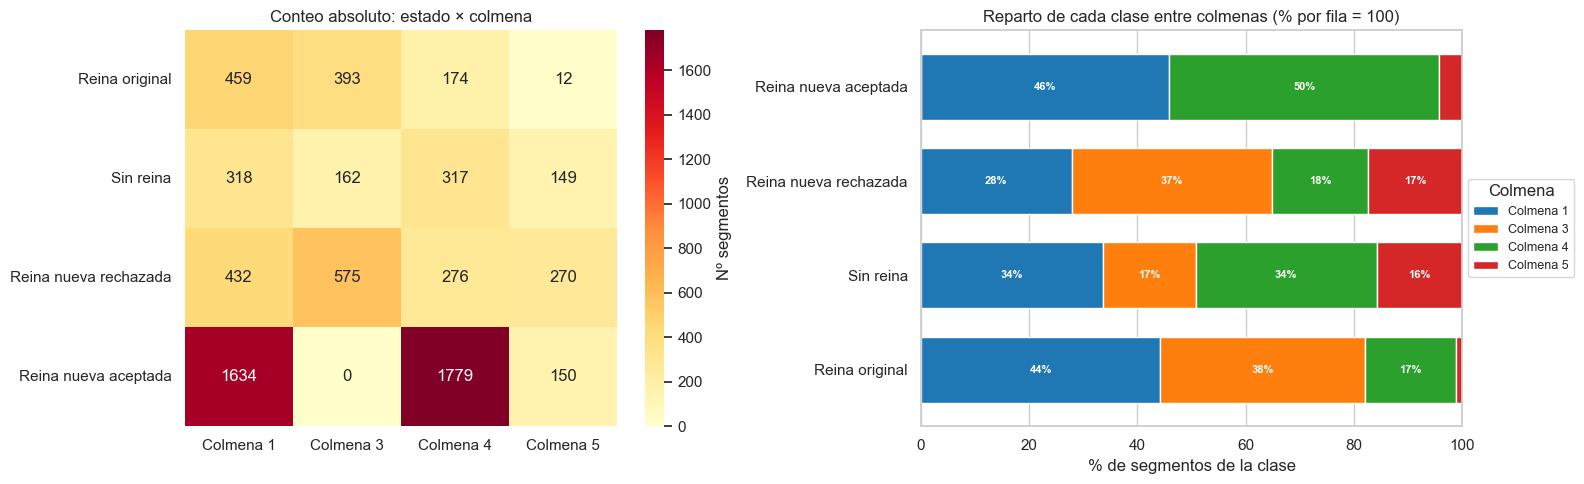

,Colmena 1,Colmena 3,Colmena 4,Colmena 5
Reina original,459,393,174,12
Sin reina,318,162,317,149
Reina nueva rechazada,432,575,276,270
Reina nueva aceptada,1634,0,1779,150


In [ ]:
tabla = pd.crosstab(df['queen status'], df['hive number'])
tabla.index = [QUEEN_STATUS_NOMBRES[i] for i in tabla.index]
tabla.columns = [f'Colmena {c}' for c in tabla.columns]

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(tabla, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Nº segmentos'}, ax=axes[0])
axes[0].set_title('Conteo absoluto: estado × colmena')
axes[0].set_xlabel(''); axes[0].set_ylabel('')

cmap_hives = plt.get_cmap('tab10')
colores_hives = [cmap_hives(i) for i in range(len(tabla_pct.columns))]
tabla_pct.plot(kind='barh', stacked=True, ax=axes[1],
               color=colores_hives, edgecolor='white', width=0.7)
axes[1].set_title('Reparto de cada clase entre colmenas (% por fila = 100)')
axes[1].set_xlabel('% de segmentos de la clase')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, title='Colmena')

for cont in axes[1].containers:
    labels = [f'{w.get_width():.0f}%' if w.get_width() > 5 else '' for w in cont]
    axes[1].bar_label(cont, labels=labels, label_type='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

tabla

---

## 3. Análisis temporal

Comprobamos el rango de fechas que cubre el dataset y si las clases están distribuidas uniformemente o concentradas en periodos concretos.

In [25]:
df['fecha'] = pd.to_datetime(df['date'], errors='coerce')
print(f'Rango temporal: {df["fecha"].min()} → {df["fecha"].max()}')
print(f'Duración total cubierta: {(df["fecha"].max() - df["fecha"].min()).days} días')
print(f'Días distintos con grabaciones: {df["fecha"].dt.date.nunique()}')

Rango temporal: 2022-06-05 17:41:01 → 2022-07-15 15:28:21
Duración total cubierta: 39 días
Días distintos con grabaciones: 34


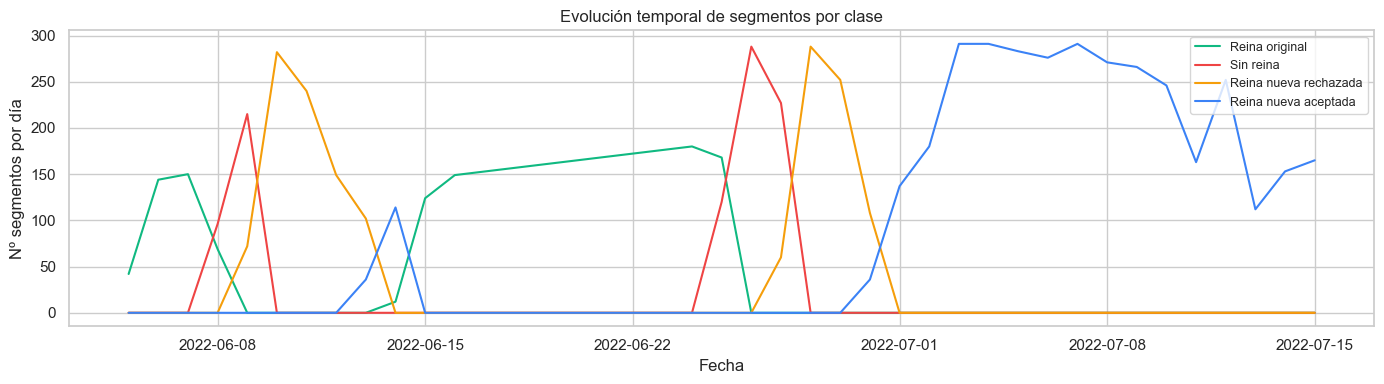

In [26]:
df['dia'] = df['fecha'].dt.date
evolucion = df.groupby(['dia', 'queen status']).size().unstack(fill_value=0)
evolucion.columns = [QUEEN_STATUS_NOMBRES[c] for c in evolucion.columns]

fig, ax = plt.subplots(figsize=(14, 4))
for col in evolucion.columns:
    cls_id = [k for k, v in QUEEN_STATUS_NOMBRES.items() if v == col][0]
    ax.plot(evolucion.index, evolucion[col], label=col, color=COLORES_CLASES[cls_id], linewidth=1.5)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº segmentos por día')
ax.set_title('Evolución temporal de segmentos por clase')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---

## 4. Análisis técnico de los audios

Comprobaciones a nivel de fichero: duración, sample rate, integridad. Para ahorrar tiempo se inspecciona una muestra aleatoria de 200 audios — suficiente para caracterizar la distribución.

In [27]:
np.random.seed(42)
muestra = df.sample(n=min(200, len(df)), random_state=42)['segmento'].tolist()

duraciones = []
sample_rates = []
errores = 0
for nombre in muestra:
    try:
        ruta = os.path.join(RUTA_AUDIOS, nombre)
        info = librosa.get_duration(path=ruta), librosa.get_samplerate(ruta)
        duraciones.append(info[0])
        sample_rates.append(info[1])
    except Exception:
        errores += 1

duraciones = np.array(duraciones)
print(f'Audios analizados: {len(duraciones)}/200  | errores: {errores}')
print(f'\nDuración: media={duraciones.mean():.2f}s | min={duraciones.min():.2f}s | max={duraciones.max():.2f}s | std={duraciones.std():.2f}s')
print(f'Sample rates únicos: {set(sample_rates)}')

Audios analizados: 200/200  | errores: 0

Duración: media=60.00s | min=60.00s | max=60.00s | std=0.00s
Sample rates únicos: {22050}


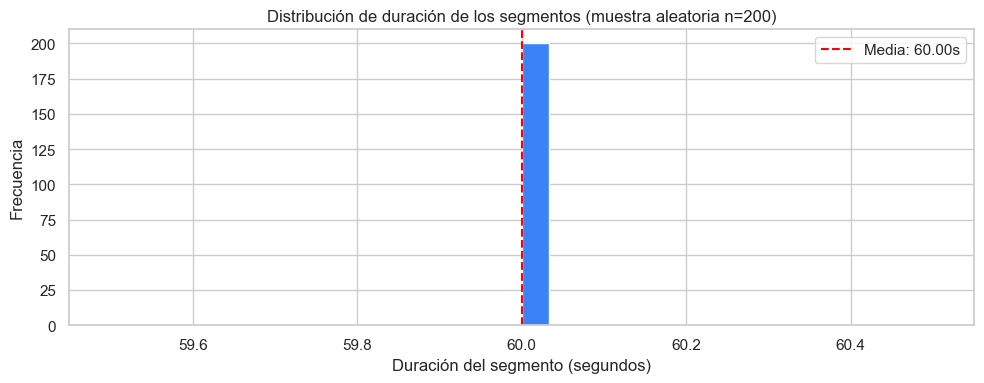

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(duraciones, bins=30, color='#3B82F6', edgecolor='white')
ax.axvline(duraciones.mean(), color='red', linestyle='--',
           label=f'Media: {duraciones.mean():.2f}s')
ax.set_xlabel('Duración del segmento (segundos)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de duración de los segmentos (muestra aleatoria n=200)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. Análisis acústico — espectrogramas

Visualización Mel-espectrograma de los audios para detectar a ojo si las clases tienen firmas acústicas diferenciables. Si las diferencias son visibles en los espectrogramas, una CNN debería ser capaz de aprenderlas.

In [ ]:
SR = 22050
N_MELS = 128
N_FFT = 2048
HOP = 512


def cargar_y_espectrograma(ruta_archivo):
    y, sr = librosa.load(ruta_archivo, sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)
    return librosa.power_to_db(mel, ref=np.max), sr

### 5.1 Un espectrograma por clase

Cogemos un audio aleatorio de cada uno de los 4 estados y los visualizamos lado a lado.

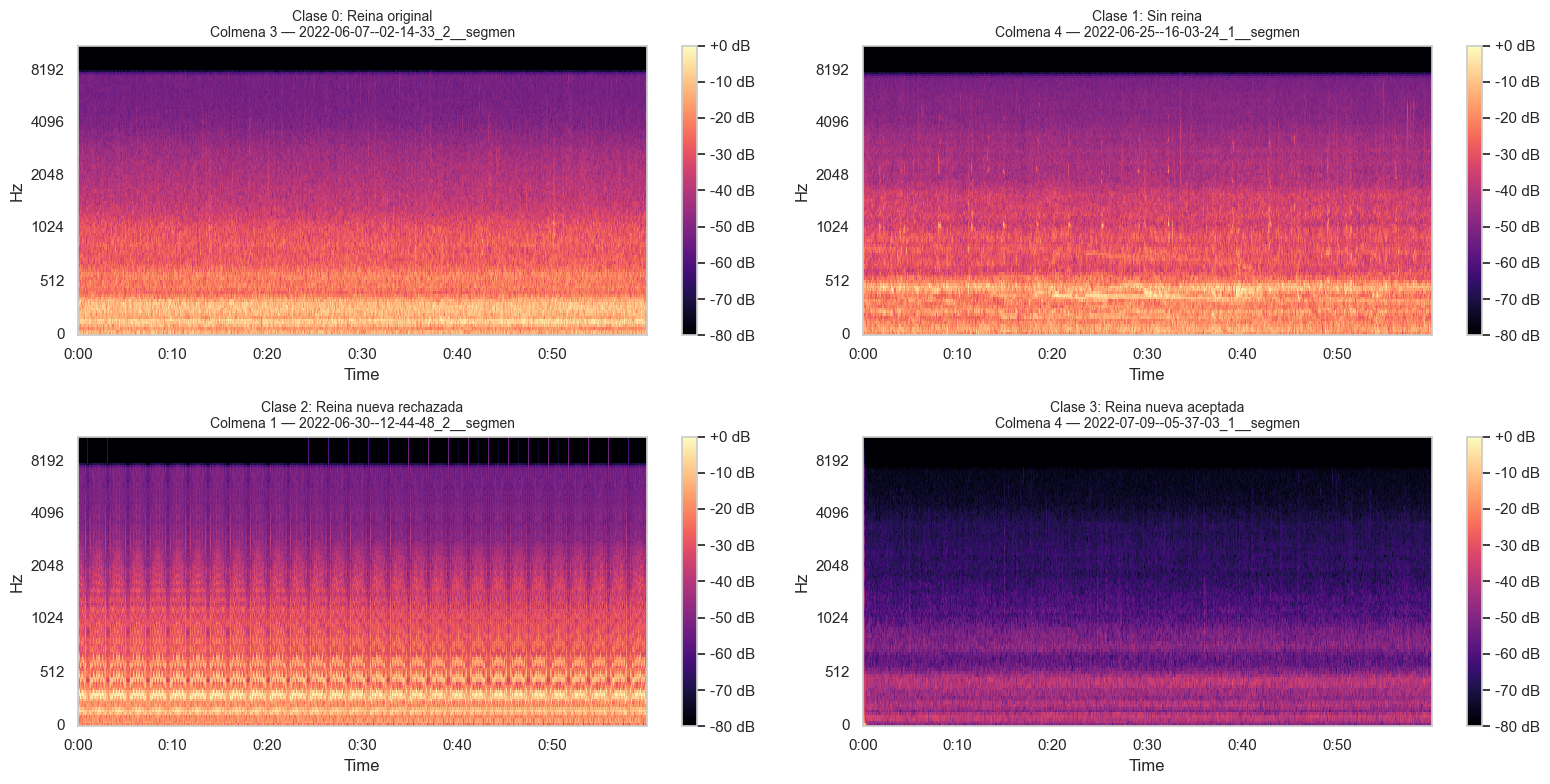

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, clase in zip(axes, sorted(QUEEN_STATUS_NOMBRES.keys())):
    sample = df[df['queen status'] == clase].sample(1, random_state=42).iloc[0]
    ruta = os.path.join(RUTA_AUDIOS, sample['segmento'])
    mel_db, sr = cargar_y_espectrograma(ruta)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='mel', cmap='magma', ax=ax)
    ax.set_title(f'Clase {clase}: {QUEEN_STATUS_NOMBRES[clase]}\nColmena {sample["hive number"]} — '
                 f'{sample["segmento"][:30]}', fontsize=10)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 5.2 Espectrograma promedio por clase

Promediar varios espectrogramas de la misma clase reduce el ruido individual y revela el **patrón típico** de cada estado. Calculamos sobre 30 audios por clase.

Clase 0: promediado sobre 30 espectrogramas
Clase 1: promediado sobre 30 espectrogramas
Clase 2: promediado sobre 30 espectrogramas
Clase 3: promediado sobre 30 espectrogramas


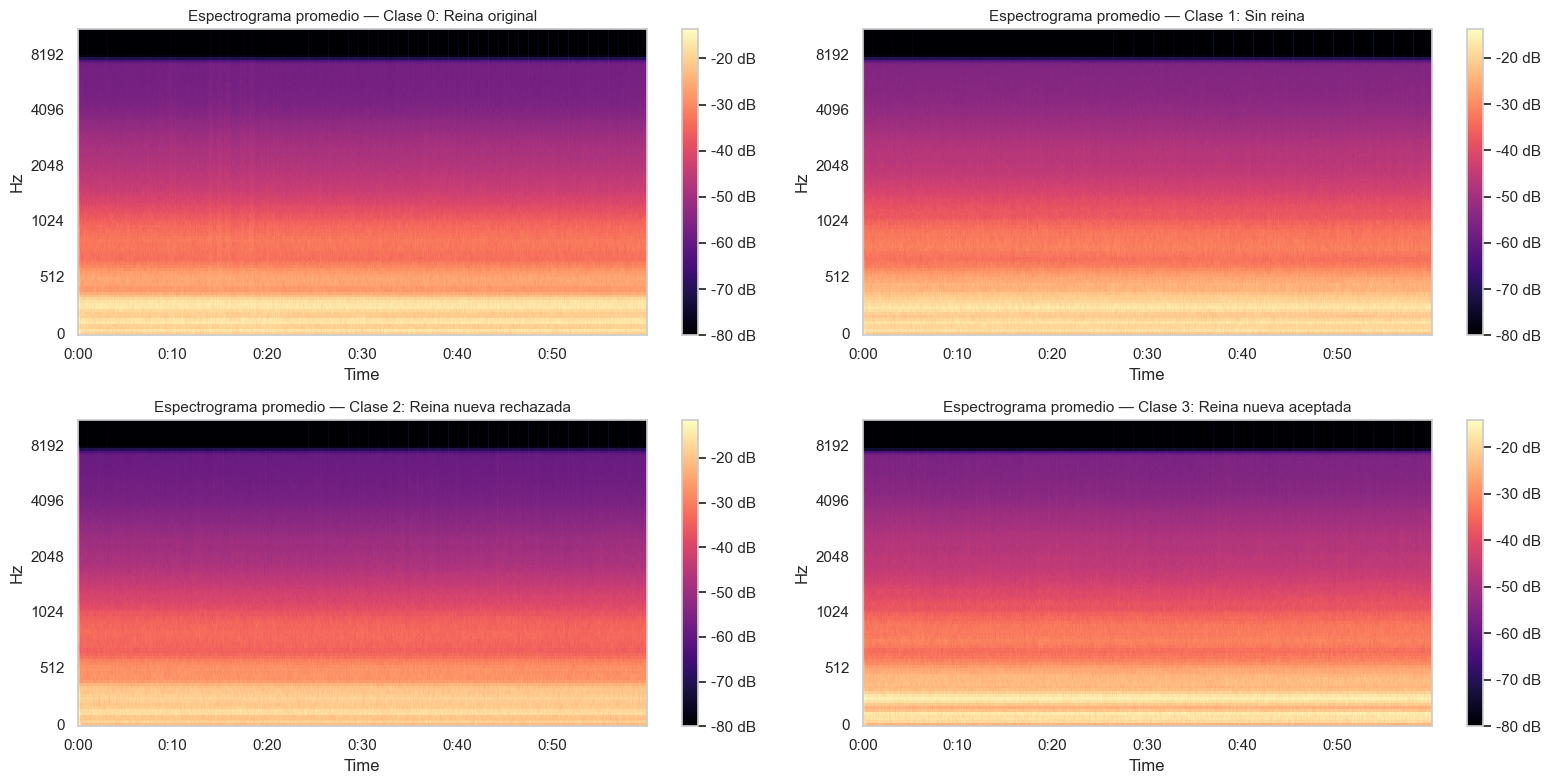

In [31]:
N_PROMEDIO = 30
promedios = {}

for clase in sorted(QUEEN_STATUS_NOMBRES.keys()):
    samples = df[df['queen status'] == clase].sample(
        min(N_PROMEDIO, (df['queen status'] == clase).sum()), random_state=42)
    espectros = []
    for _, row in samples.iterrows():
        ruta = os.path.join(RUTA_AUDIOS, row['segmento'])
        try:
            mel_db, _ = cargar_y_espectrograma(ruta)
            # Recortar todos a la misma longitud temporal (la del más corto)
            espectros.append(mel_db)
        except Exception:
            continue
    if espectros:
        # Truncar todos a la longitud del más corto para promediar
        T_min = min(e.shape[1] for e in espectros)
        espectros = [e[:, :T_min] for e in espectros]
        promedios[clase] = np.mean(espectros, axis=0)
        print(f'Clase {clase}: promediado sobre {len(espectros)} espectrogramas')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
for ax, (clase, mel_avg) in zip(axes, sorted(promedios.items())):
    img = librosa.display.specshow(mel_avg, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel',
                                    cmap='magma', ax=ax)
    ax.set_title(f'Espectrograma promedio — Clase {clase}: {QUEEN_STATUS_NOMBRES[clase]}', fontsize=11)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.show()

### 5.3 Espectro de potencia por clase (frecuencias dominantes)

El zumbido de una colmena sana tiene un pico característico alrededor de los **250-300 Hz**. Comprobamos si se puede ver este pico en los datos y si las clases anómalas tienen otros picos en frecuencias diferentes.

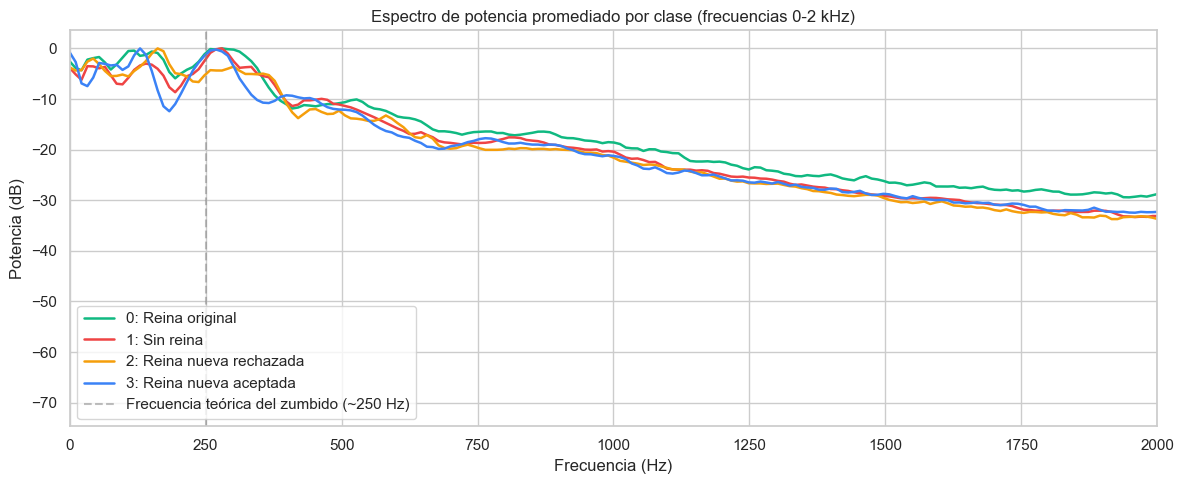

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for clase in sorted(QUEEN_STATUS_NOMBRES.keys()):
    samples = df[df['queen status'] == clase].sample(
        min(20, (df['queen status'] == clase).sum()), random_state=42)
    espectros_potencia = []
    for _, row in samples.iterrows():
        ruta = os.path.join(RUTA_AUDIOS, row['segmento'])
        try:
            y, sr = librosa.load(ruta, sr=SR, mono=True)
            S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)) ** 2
            espectros_potencia.append(S.mean(axis=1))  # promedio temporal
        except Exception:
            continue
    if espectros_potencia:
        espectro_promedio = np.mean(espectros_potencia, axis=0)
        freqs = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
        spec_db = librosa.power_to_db(espectro_promedio, ref=np.max)
        ax.plot(freqs, spec_db, color=COLORES_CLASES[clase], linewidth=1.8,
                label=f'{clase}: {QUEEN_STATUS_NOMBRES[clase]}')

ax.axvline(250, color='gray', linestyle='--', alpha=0.5, label='Frecuencia teórica del zumbido (~250 Hz)')
ax.set_xlim(0, 2000)
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Potencia (dB)')
ax.set_title('Espectro de potencia promediado por clase (frecuencias 0-2 kHz)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()